# LAB 5

#### EDA

In [87]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df=pd.read_csv('garments_worker_productivity.csv')

In [89]:
df.head()
df.info()
df.columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [90]:
print("Unique dates:", df['date'].nunique())

print("\nWIP statistics:")
print(df['wip'].describe())

print("\nTarget statistics:")
print(df['actual_productivity'].describe())

print("\nTargeted productivity statistics:")
print(df['targeted_productivity'].describe())

Unique dates: 59

WIP statistics:
count      691.000000
mean      1190.465991
std       1837.455001
min          7.000000
25%        774.500000
50%       1039.000000
75%       1252.500000
max      23122.000000
Name: wip, dtype: float64

Target statistics:
count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

Targeted productivity statistics:
count    1197.000000
mean        0.729632
std         0.097891
min         0.070000
25%         0.700000
50%         0.750000
75%         0.800000
max         0.800000
Name: targeted_productivity, dtype: float64


In [91]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


In [92]:
print("\nNumerical Summary:")
print(df.describe())


Numerical Summary:
              team  targeted_productivity          smv           wip  \
count  1197.000000            1197.000000  1197.000000    691.000000   
mean      6.426901               0.729632    15.062172   1190.465991   
std       3.463963               0.097891    10.943219   1837.455001   
min       1.000000               0.070000     2.900000      7.000000   
25%       3.000000               0.700000     3.940000    774.500000   
50%       6.000000               0.750000    15.260000   1039.000000   
75%       9.000000               0.800000    24.260000   1252.500000   
max      12.000000               0.800000    54.560000  23122.000000   

          over_time    incentive    idle_time     idle_men  \
count   1197.000000  1197.000000  1197.000000  1197.000000   
mean    4567.460317    38.210526     0.730159     0.369256   
std     3348.823563   160.182643    12.709757     3.268987   
min        0.000000     0.000000     0.000000     0.000000   
25%     1440.000000  

In [93]:
categorical_columns = ['date', 'quarter', 'department', 'day']

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


date:
['1/1/2015' '1/3/2015' '1/4/2015' '1/5/2015' '1/6/2015' '1/7/2015'
 '1/8/2015' '1/10/2015' '1/11/2015' '1/12/2015' '1/13/2015' '1/14/2015'
 '1/15/2015' '1/17/2015' '1/18/2015' '1/19/2015' '1/20/2015' '1/21/2015'
 '1/22/2015' '1/24/2015' '1/25/2015' '1/26/2015' '1/27/2015' '1/28/2015'
 '1/29/2015' '1/31/2015' '2/1/2015' '2/2/2015' '2/3/2015' '2/4/2015'
 '2/5/2015' '2/7/2015' '2/8/2015' '2/9/2015' '2/10/2015' '2/11/2015'
 '2/12/2015' '2/14/2015' '2/15/2015' '2/16/2015' '2/17/2015' '2/18/2015'
 '2/19/2015' '2/22/2015' '2/23/2015' '2/24/2015' '2/25/2015' '2/26/2015'
 '2/28/2015' '3/1/2015' '3/2/2015' '3/3/2015' '3/4/2015' '3/5/2015'
 '3/7/2015' '3/8/2015' '3/9/2015' '3/10/2015' '3/11/2015']

quarter:
['Quarter1' 'Quarter2' 'Quarter3' 'Quarter4' 'Quarter5']

department:
['sweing' 'finishing ' 'finishing']

day:
['Thursday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday']


In [94]:
print("\nDepartment value counts:")
print(df['department'].value_counts())


Department value counts:
sweing        691
finishing     257
finishing     249
Name: department, dtype: int64


In [95]:
print("\nWIP missing values by department:")
print(
    pd.crosstab(
        df['department'].str.strip(),
        df['wip'].isna(),
        margins=True
    )
)


WIP missing values by department:
wip         False  True   All
department                   
finishing       0   506   506
sweing        691     0   691
All           691   506  1197


In [96]:
print("\nNumber of unique dates:", df['date'].nunique())


Number of unique dates: 59


## Data Cleaning & Feature Engineering

Clean categorical whitespace

In [97]:
df['department'] = df['department'].str.strip()

In [98]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day
df.drop(columns=['date'], inplace=True)

Create Targets

In [99]:
df['MeetsTarget'] = (
    df['actual_productivity'] >= df['targeted_productivity']
).astype(int)

In [100]:
print(df['MeetsTarget'].value_counts())

1    875
0    322
Name: MeetsTarget, dtype: int64


In [101]:
print("\nClass proportions:")
print(df['MeetsTarget'].value_counts(normalize=True))


Class proportions:
1    0.730994
0    0.269006
Name: MeetsTarget, dtype: float64


## Train-Test Split


In [102]:
# Fixed random seed for reproducibility
np.random.seed(42)

# Get indices for each class
class_0_indices = df.index[df['MeetsTarget'] == 0].to_numpy()
class_1_indices = df.index[df['MeetsTarget'] == 1].to_numpy()

# Shuffle the indices within each class
np.random.shuffle(class_0_indices)
np.random.shuffle(class_1_indices)

# 80% of each class for training
train_0_size = int(0.8 * len(class_0_indices))
train_1_size = int(0.8 * len(class_1_indices))

# Create training indices
train_indices = np.concatenate([
    class_0_indices[:train_0_size],
    class_1_indices[:train_1_size]
])

# Create testing indices
test_indices = np.concatenate([
    class_0_indices[train_0_size:],
    class_1_indices[train_1_size:]
])

# Shuffle the final train and test indices
np.random.shuffle(train_indices)
np.random.shuffle(test_indices)

print("Training samples:", len(train_indices))
print("Testing samples:", len(test_indices))

Training samples: 957
Testing samples: 240



The class distribution of `MeetsTarget` is checked separately in the training and testing sets to verify that the stratified split approximately preserves the original class proportions.

In [103]:
print("Original class distribution:")
print(df['MeetsTarget'].value_counts())

print("\nTraining class distribution:")
print(df.loc[train_indices, 'MeetsTarget'].value_counts())

print("\nTesting class distribution:")
print(df.loc[test_indices, 'MeetsTarget'].value_counts())

print("\nOriginal proportions:")
print(df['MeetsTarget'].value_counts(normalize=True))

print("\nTraining proportions:")
print(df.loc[train_indices, 'MeetsTarget'].value_counts(normalize=True))

print("\nTesting proportions:")
print(df.loc[test_indices, 'MeetsTarget'].value_counts(normalize=True))

Original class distribution:
1    875
0    322
Name: MeetsTarget, dtype: int64

Training class distribution:
1    700
0    257
Name: MeetsTarget, dtype: int64

Testing class distribution:
1    175
0     65
Name: MeetsTarget, dtype: int64

Original proportions:
1    0.730994
0    0.269006
Name: MeetsTarget, dtype: float64

Training proportions:
1    0.731452
0    0.268548
Name: MeetsTarget, dtype: float64

Testing proportions:
1    0.729167
0    0.270833
Name: MeetsTarget, dtype: float64


In [104]:
overlap = np.intersect1d(train_indices, test_indices)

print("Number of overlapping indices:", len(overlap))

all_split_indices = np.concatenate([train_indices, test_indices])

print("Total rows in dataset:", len(df))
print("Total rows in split:", len(all_split_indices))
print("Unique rows in split:", len(np.unique(all_split_indices)))

Number of overlapping indices: 0
Total rows in dataset: 1197
Total rows in split: 1197
Unique rows in split: 1197


Verification of Train-Test Separation

The training and testing indices are checked to ensure that there is no overlap between the two sets.

### Creating Fixed Training and Testing Data

The verified indices are used to create the training and testing DataFrames. No preprocessing is performed at this stage because preprocessing parameters such as the WIP median and scaling statistics must be learned from the training data only.

In [105]:
train_df = df.loc[train_indices].copy()
test_df = df.loc[test_indices].copy()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (957, 17)
Testing shape: (240, 17)


## Preprocessing

In [106]:
# Numerical features
numerical_features = [
    'team',
    'targeted_productivity',
    'smv',
    'wip',
    'over_time',
    'incentive',
    'idle_time',
    'idle_men',
    'no_of_style_change',
    'no_of_workers',
    'month',
    'day_of_month'
]

# Categorical features
categorical_features = [
    'quarter',
    'department',
    'day'
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'month', 'day_of_month']

Categorical features:
['quarter', 'department', 'day']


#### Part A- Scikit-learn Preprocessing

In [107]:
#inports
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [108]:
# Numerical preprocessing
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

Sparse representation saves memory when most values are zero; dense representation is simpler when the feature matrix is small.

In [109]:
#Column transformer to apply the pipelines to the respective features
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

In [110]:
# Fit preprocessing using training features only
preprocessor.fit(train_df[numerical_features + categorical_features])

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['team', 'targeted_productivity', 'smv', 'wip',
                                  'over_time', 'incentive', 'idle_time',
                                  'idle_men', 'no_of_style_change',
                                  'no_of_workers', 'month', 'day_of_month']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['quarter', 'department', 'day'])])

In [111]:
# Transform both training and testing features
X_train_processed = preprocessor.transform(
    train_df[numerical_features + categorical_features]
)

X_test_processed = preprocessor.transform(
    test_df[numerical_features + categorical_features]
)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (957, 25)
Processed testing shape: (240, 25)


In [112]:
# Get the processed feature names
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
print(feature_names)

Number of processed features: 25

Processed feature names:
['numerical__team' 'numerical__targeted_productivity' 'numerical__smv'
 'numerical__wip' 'numerical__over_time' 'numerical__incentive'
 'numerical__idle_time' 'numerical__idle_men'
 'numerical__no_of_style_change' 'numerical__no_of_workers'
 'numerical__month' 'numerical__day_of_month'
 'categorical__quarter_Quarter1' 'categorical__quarter_Quarter2'
 'categorical__quarter_Quarter3' 'categorical__quarter_Quarter4'
 'categorical__quarter_Quarter5' 'categorical__department_finishing'
 'categorical__department_sweing' 'categorical__day_Monday'
 'categorical__day_Saturday' 'categorical__day_Sunday'
 'categorical__day_Thursday' 'categorical__day_Tuesday'
 'categorical__day_Wednesday']


In [113]:
# Check for missing values in the processed data
print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [114]:
#VERIFICATION
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
print("Number of processed features:", len(feature_names))

print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Processed training shape: (957, 25)
Processed testing shape: (240, 25)
Number of processed features: 25
Missing values in processed training data: 0
Missing values in processed testing data: 0


#### Scikit-learn Preprocessing

In this step, the cleaned training and testing datasets are transformed into numerical feature matrices suitable for machine-learning models using Scikit-learn preprocessing utilities.

The preprocessing is divided into two pipelines based on feature type:

- **Numerical features:** Missing `wip` values are handled using median imputation, followed by standardization using `StandardScaler`.
- **Categorical features:** Missing categorical values, if any, are handled using the most frequent category, followed by one-hot encoding using `OneHotEncoder`.

The numerical and categorical pipelines are combined using `ColumnTransformer`.

A crucial requirement is that the preprocessing object is **fitted only on the training data**. Therefore, the median used for `wip` imputation, the mean and standard deviation used for scaling, and the categories learned during encoding are obtained only from the training set. The fitted transformations are then applied to both the training and testing data.

This prevents **data leakage**, where information from the test set could influence the training process.

The resulting processed matrices, `X_train_processed` and `X_test_processed`, contain only numerical values and no missing values. These matrices will serve as the common preprocessed input for the Scikit-learn regression and classification models in Part A.

#### 5B — Manual Preprocessing

No sklearn preprocessing, models, metrics, or train-test utilities will be used in Part B.

| sklearn                 | Our implementation          |
| ----------------------- | --------------------------- |
| `SimpleImputer(median)` | Pandas median               |
| `OneHotEncoder`         | `pd.get_dummies()` / NumPy  |
| `StandardScaler`        | manually calculate mean/std |
| `ColumnTransformer`     | manually combine DataFrames |


In [115]:
# Calculate WIP median using training data only
#WIP Median Imputation
wip_median = train_df['wip'].median()

print("Training WIP median:", wip_median)

# Make copies so the original train/test data remain unchanged
train_manual = train_df.copy()
test_manual = test_df.copy()

# Impute missing WIP values using the training median
train_manual['wip'] = train_manual['wip'].fillna(wip_median)
test_manual['wip'] = test_manual['wip'].fillna(wip_median)

print("Missing WIP in training after imputation:",
      train_manual['wip'].isna().sum())

print("Missing WIP in testing after imputation:",
      test_manual['wip'].isna().sum())

Training WIP median: 1038.0
Missing WIP in training after imputation: 0
Missing WIP in testing after imputation: 0


In [116]:
# Create one-hot encoded columns using the training data
#Manual One-Hot Encoding
train_categorical = pd.get_dummies(
    train_manual[categorical_features],
    prefix=categorical_features,
    dtype=int
)

print("Training categorical shape:", train_categorical.shape)
print("\nTraining categorical columns:")
print(train_categorical.columns.tolist())

Training categorical shape: (957, 13)

Training categorical columns:
['quarter_Quarter1', 'quarter_Quarter2', 'quarter_Quarter3', 'quarter_Quarter4', 'quarter_Quarter5', 'department_finishing', 'department_sweing', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']


In [117]:
# Create one-hot encoded columns for the test data
#Manual One-Hot Encoding
test_categorical = pd.get_dummies(
    test_manual[categorical_features],
    prefix=categorical_features,
    dtype=int
)

# Align test columns with training columns
test_categorical = test_categorical.reindex(
    columns=train_categorical.columns,
    fill_value=0
)

print("Testing categorical shape:", test_categorical.shape)

print("\nSame categorical columns:",
      list(train_categorical.columns) == list(test_categorical.columns))

Testing categorical shape: (240, 13)

Same categorical columns: True


In [118]:
#verify that the number of categorical columns matches between training and testing
print("Training categorical columns:", train_categorical.shape[1])
print("Testing categorical columns:", test_categorical.shape[1])

print("\nColumn mismatch:",
      set(train_categorical.columns) ^ set(test_categorical.columns))

Training categorical columns: 13
Testing categorical columns: 13

Column mismatch: set()


In [119]:
#Manual Feature Scaling
# Calculate mean and standard deviation using training data only
train_means = train_manual[numerical_features].mean()
train_stds = train_manual[numerical_features].std()

print("Training means:")
print(train_means)

print("\nTraining standard deviations:")
print(train_stds)

Training means:
team                        6.452456
targeted_productivity       0.725726
smv                        15.140073
wip                      1110.163009
over_time                4595.287356
incentive                  35.933124
idle_time                   0.900731
idle_men                    0.393939
no_of_style_change          0.151515
no_of_workers              34.675549
month                       1.721003
day_of_month               13.467085
dtype: float64

Training standard deviations:
team                        3.479631
targeted_productivity       0.101098
smv                        10.951937
wip                      1220.829095
over_time                3335.184656
incentive                 128.400498
idle_time                  14.209011
idle_men                    3.433542
no_of_style_change          0.427886
no_of_workers              22.217732
month                       0.749133
day_of_month                8.676678
dtype: float64


In [120]:
# Convert training numerical data to NumPy
X_train_num = train_manual[numerical_features].to_numpy(dtype=float)

# Calculate training mean and population standard deviation
train_means = np.mean(X_train_num, axis=0)
train_stds = np.std(X_train_num, axis=0, ddof=0)

print("Training means:")
print(train_means)

print("\nTraining standard deviations:")
print(train_stds)

Training means:
[6.45245559e+00 7.25726228e-01 1.51400731e+01 1.11016301e+03
 4.59528736e+03 3.59331243e+01 9.00731452e-01 3.93939394e-01
 1.51515152e-01 3.46755486e+01 1.72100313e+00 1.34670846e+01]

Training standard deviations:
[3.47781245e+00 1.01044805e-01 1.09462138e+01 1.22019109e+03
 3.33344168e+03 1.28333396e+02 1.42015853e+01 3.43174754e+00
 4.27661991e-01 2.22061211e+01 7.48741778e-01 8.67214359e+00]


In [121]:
# Convert numerical features to NumPy arrays
X_train_num = train_manual[numerical_features].to_numpy(dtype=float)
X_test_num = test_manual[numerical_features].to_numpy(dtype=float)

# Manual standardization
X_train_num_scaled = (X_train_num - train_means) / train_stds
X_test_num_scaled = (X_test_num - train_means) / train_stds

print("Scaled training numerical shape:",
      X_train_num_scaled.shape)

print("Scaled testing numerical shape:",
      X_test_num_scaled.shape)

Scaled training numerical shape: (957, 12)
Scaled testing numerical shape: (240, 12)


In [122]:
# Convert categorical data to NumPy arrays
X_train_cat = train_categorical.to_numpy(dtype=float)
X_test_cat = test_categorical.to_numpy(dtype=float)

# Combine numerical and categorical features
X_train_manual = np.hstack([
    X_train_num_scaled,
    X_train_cat
])

X_test_manual = np.hstack([
    X_test_num_scaled,
    X_test_cat
])

print("Manual training shape:", X_train_manual.shape)
print("Manual testing shape:", X_test_manual.shape)

Manual training shape: (957, 25)
Manual testing shape: (240, 25)


In [123]:
#Verficiation of manual and sklearn processed data
print("Manual train shape:", X_train_manual.shape)
print("Manual test shape:", X_test_manual.shape)

print("\nNaN values in manual train:",
      np.isnan(X_train_manual).sum())

print("NaN values in manual test:",
      np.isnan(X_test_manual).sum())

print("\nSklearn train shape:", X_train_processed.shape)
print("Sklearn test shape:", X_test_processed.shape)

Manual train shape: (957, 25)
Manual test shape: (240, 25)

NaN values in manual train: 0
NaN values in manual test: 0

Sklearn train shape: (957, 25)
Sklearn test shape: (240, 25)


In [124]:
# Compare manual preprocessing with Scikit-learn preprocessing

train_difference = np.max(
    np.abs(X_train_processed - X_train_manual)
)

test_difference = np.max(
    np.abs(X_test_processed - X_test_manual)
)

print("Maximum absolute difference - training:",
      train_difference)

print("Maximum absolute difference - testing:",
      test_difference)

Maximum absolute difference - training: 0.0
Maximum absolute difference - testing: 0.0


Manual Preprocessing Summary and Verification

The preprocessing workflow was reproduced manually using only **NumPy and Pandas**, without using Scikit-learn preprocessing utilities.

First, missing values in the `wip` feature were handled using the **median calculated from the training data only**. The same median was applied to the testing data to prevent data leakage.

The categorical features were then converted into numerical form using **one-hot encoding**. The testing categorical columns were aligned with the training columns so that both datasets had the same feature structure.

Next, the numerical features were standardized manually using the training-set mean and population standard deviation:

\[
z = \frac{x-\mu}{\sigma}
\]

The training statistics were reused for the testing data, ensuring that no information from the test set was used during preprocessing.

The scaled numerical features and one-hot encoded categorical features were then combined to form the final feature matrices. Both the training and testing matrices contained **25 features**.

Finally, the manual preprocessing output was compared with the Scikit-learn preprocessing output. The maximum absolute difference was:

- Training data: `0.0`
- Testing data: `0.0`

Therefore, the manual preprocessing implementation reproduced the Scikit-learn preprocessing output **exactly** for this dataset. This verifies that missing-value handling, categorical encoding, scaling, feature ordering, and feature combination were implemented correctly while maintaining the required separation between training and testing data.

### Part A — Scikit-learn Models.

In [125]:
#Creating Regression and Classification Targets
# Regression targets
y_train_reg = train_df['actual_productivity'].to_numpy()
y_test_reg = test_df['actual_productivity'].to_numpy()

# Classification targets
y_train_cls = train_df['MeetsTarget'].to_numpy()
y_test_cls = test_df['MeetsTarget'].to_numpy()

print("Regression target shapes:")
print("Training:", y_train_reg.shape)
print("Testing :", y_test_reg.shape)

print("\nClassification target shapes:")
print("Training:", y_train_cls.shape)
print("Testing :", y_test_cls.shape)

Regression target shapes:
Training: (957,)
Testing : (240,)

Classification target shapes:
Training: (957,)
Testing : (240,)


##### Linear Regression

In [126]:
#Linear regression model
from sklearn.linear_model import LinearRegression
import time

# Create the Linear Regression model
linear_model = LinearRegression()

# Measure training time
start_time = time.perf_counter()

linear_model.fit(X_train_processed, y_train_reg)

train_time_lr = time.perf_counter() - start_time

# Measure prediction time
start_time = time.perf_counter()

y_train_pred_lr = linear_model.predict(X_train_processed)
y_test_pred_lr = linear_model.predict(X_test_processed)

prediction_time_lr = time.perf_counter() - start_time

print("Linear Regression")
print("-----------------")
print(f"Training time   : {train_time_lr:.6f} seconds")
print(f"Prediction time : {prediction_time_lr:.6f} seconds")

Linear Regression
-----------------
Training time   : 0.046346 seconds
Prediction time : 0.005806 seconds


In [127]:
#Evaluating Scikit-learn Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Training metrics
train_mae_lr = mean_absolute_error(y_train_reg, y_train_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_lr))
train_r2_lr = r2_score(y_train_reg, y_train_pred_lr)

# Testing metrics
test_mae_lr = mean_absolute_error(y_test_reg, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_lr))
test_r2_lr = r2_score(y_test_reg, y_test_pred_lr)

print("Scikit-learn Linear Regression Metrics")
print("--------------------------------------")
print(f"Train MAE  : {train_mae_lr:.4f}")
print(f"Train RMSE : {train_rmse_lr:.4f}")
print(f"Train R²   : {train_r2_lr:.4f}")

print()

print(f"Test MAE   : {test_mae_lr:.4f}")
print(f"Test RMSE  : {test_rmse_lr:.4f}")
print(f"Test R²    : {test_r2_lr:.4f}")

Scikit-learn Linear Regression Metrics
--------------------------------------
Train MAE  : 0.1060
Train RMSE : 0.1465
Train R²   : 0.3020

Test MAE   : 0.1083
Test RMSE  : 0.1451
Test R²    : 0.2754


##### Logistic Regression

In [128]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
import time

# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Measure training time
start_time = time.perf_counter()

logistic_model.fit(X_train_processed, y_train_cls)

train_time_log = time.perf_counter() - start_time

# Measure prediction time
start_time = time.perf_counter()

y_train_pred_log = logistic_model.predict(X_train_processed)
y_test_pred_log = logistic_model.predict(X_test_processed)

prediction_time_log = time.perf_counter() - start_time

print("Logistic Regression")
print("-------------------")
print(f"Training time   : {train_time_log:.6f} seconds")
print(f"Prediction time : {prediction_time_log:.6f} seconds")

Logistic Regression
-------------------
Training time   : 0.121982 seconds
Prediction time : 0.001861 seconds


In [129]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Training metrics
train_accuracy_log = accuracy_score(y_train_cls, y_train_pred_log)
train_precision_log = precision_score(y_train_cls, y_train_pred_log)
train_recall_log = recall_score(y_train_cls, y_train_pred_log)
train_f1_log = f1_score(y_train_cls, y_train_pred_log)

# Testing metrics
test_accuracy_log = accuracy_score(y_test_cls, y_test_pred_log)
test_precision_log = precision_score(y_test_cls, y_test_pred_log)
test_recall_log = recall_score(y_test_cls, y_test_pred_log)
test_f1_log = f1_score(y_test_cls, y_test_pred_log)

print("Scikit-learn Logistic Regression Metrics")
print("----------------------------------------")
print(f"Train Accuracy  : {train_accuracy_log:.4f}")
print(f"Train Precision : {train_precision_log:.4f}")
print(f"Train Recall    : {train_recall_log:.4f}")
print(f"Train F1-score  : {train_f1_log:.4f}")

print()

print(f"Test Accuracy   : {test_accuracy_log:.4f}")
print(f"Test Precision  : {test_precision_log:.4f}")
print(f"Test Recall     : {test_recall_log:.4f}")
print(f"Test F1-score   : {test_f1_log:.4f}")

Scikit-learn Logistic Regression Metrics
----------------------------------------
Train Accuracy  : 0.7722
Train Precision : 0.7918
Train Recall    : 0.9343
Train F1-score  : 0.8571

Test Accuracy   : 0.6958
Test Precision  : 0.7500
Test Recall     : 0.8743
Test F1-score   : 0.8074


Summary

For the regression task, Scikit-learn `LinearRegression` was used to predict `actual_productivity`. The model achieved a test MAE of 0.1083, test RMSE of 0.1451, and test \(R^2\) of 0.2754.

For the classification task, Scikit-learn `LogisticRegression` was used to predict `MeetsTarget`. The model achieved a test accuracy of 0.6958, precision of 0.7500, recall of 0.8743, and F1-score of 0.8074.

Training and prediction times were also recorded for both models. These results provide the Scikit-learn baseline that will be compared with the manually implemented models in Part B.

The same fixed train-test split and preprocessing approach are used throughout the assignment to ensure a fair comparison between Scikit-learn and the from-scratch implementations.

| Model               |   Training | Prediction |
| ------------------- | ---------: | ---------: |
| Linear Regression   | 0.144629 s | 0.005928 s |
| Logistic Regression | 0.178836 s | 0.003666 s |


#### Manual Linear Regression using the Moore-Penrose pseudoinverse

In [130]:
# Add a column of ones for the intercept(beta_0) term in the regression model
X_train_reg_bias = np.hstack([
    np.ones((X_train_manual.shape[0], 1)),
    X_train_manual
])

X_test_reg_bias = np.hstack([
    np.ones((X_test_manual.shape[0], 1)),
    X_test_manual
])

print("Original training shape :", X_train_manual.shape)
print("With intercept          :", X_train_reg_bias.shape)

print("Original testing shape  :", X_test_manual.shape)
print("With intercept           :", X_test_reg_bias.shape)

Original training shape : (957, 25)
With intercept          : (957, 26)
Original testing shape  : (240, 25)
With intercept           : (240, 26)


In [131]:
# Calculate the Moore-Penrose pseudoinverse
X_train_pinv = np.linalg.pinv(X_train_reg_bias)

# Calculate regression coefficients
beta = X_train_pinv @ y_train_reg

print("Pseudoinverse shape:", X_train_pinv.shape)
print("Coefficient vector shape:", beta.shape)
print("\nIntercept:", beta[0])
print("Number of feature coefficients:", len(beta) - 1)

Pseudoinverse shape: (26, 957)
Coefficient vector shape: (26,)

Intercept: 0.4003746016931457
Number of feature coefficients: 25


In [132]:
# Generate predictions using the learned coefficients
y_train_pred_manual_lr = X_train_reg_bias @ beta
y_test_pred_manual_lr = X_test_reg_bias @ beta

print("Training predictions shape:", y_train_pred_manual_lr.shape)
print("Testing predictions shape :", y_test_pred_manual_lr.shape)

print("\nFirst 5 training predictions:")
print(y_train_pred_manual_lr[:5])

print("\nFirst 5 testing predictions:")
print(y_test_pred_manual_lr[:5])# Generate predictions using the learned coefficients
y_train_pred_manual_lr = X_train_reg_bias @ beta
y_test_pred_manual_lr = X_test_reg_bias @ beta

print("Training predictions shape:", y_train_pred_manual_lr.shape)
print("Testing predictions shape :", y_test_pred_manual_lr.shape)

print("\nFirst 5 training predictions:")
print(y_train_pred_manual_lr[:5])

print("\nFirst 5 testing predictions:")
print(y_test_pred_manual_lr[:5])

Training predictions shape: (957,)
Testing predictions shape : (240,)

First 5 training predictions:
[0.78501256 0.74585907 0.81672776 0.874188   0.81944312]

First 5 testing predictions:
[0.85193399 0.70204569 0.76152655 0.62613091 0.73400951]
Training predictions shape: (957,)
Testing predictions shape : (240,)

First 5 training predictions:
[0.78501256 0.74585907 0.81672776 0.874188   0.81944312]

First 5 testing predictions:
[0.85193399 0.70204569 0.76152655 0.62613091 0.73400951]


In [133]:
# Manual regression metrics

def calculate_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def calculate_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


# Training metrics
train_mae_manual = calculate_mae(
    y_train_reg, y_train_pred_manual_lr
)

train_rmse_manual = calculate_rmse(
    y_train_reg, y_train_pred_manual_lr
)

train_r2_manual = calculate_r2(
    y_train_reg, y_train_pred_manual_lr
)


# Testing metrics
test_mae_manual = calculate_mae(
    y_test_reg, y_test_pred_manual_lr
)

test_rmse_manual = calculate_rmse(
    y_test_reg, y_test_pred_manual_lr
)

test_r2_manual = calculate_r2(
    y_test_reg, y_test_pred_manual_lr
)


print("Manual Linear Regression Metrics")
print("--------------------------------")
print(f"Train MAE  : {train_mae_manual:.4f}")
print(f"Train RMSE : {train_rmse_manual:.4f}")
print(f"Train R²   : {train_r2_manual:.4f}")

print()

print(f"Test MAE   : {test_mae_manual:.4f}")
print(f"Test RMSE  : {test_rmse_manual:.4f}")
print(f"Test R²    : {test_r2_manual:.4f}")

Manual Linear Regression Metrics
--------------------------------
Train MAE  : 0.1060
Train RMSE : 0.1465
Train R²   : 0.3020

Test MAE   : 0.1083
Test RMSE  : 0.1451
Test R²    : 0.2754


Summary

Linear Regression was implemented from scratch using NumPy and the Moore-Penrose pseudoinverse.

A column of ones was added to the preprocessed feature matrix to explicitly represent the intercept term. The regression coefficients were then calculated using:

\[
beta = X^+y
\]



The regression evaluation metrics were also implemented manually using NumPy.

The manually implemented model produced the same results as the Scikit-learn Linear Regression model:

- **Train MAE:** 0.1060
- **Train RMSE:** 0.1465
- **Train \(R^2\):** 0.3020
- **Test MAE:** 0.1083
- **Test RMSE:** 0.1451
- **Test \(R^2\):** 0.2754

The identical results verify that the manual pseudoinverse implementation correctly reproduces the Scikit-learn Linear Regression solution for this dataset.
There is a small difference between training and testing R², with the training R² being 0.3020 and testing R² being 0.2754. However, the gap is small and the MAE and RMSE are also very similar, so the results do not indicate substantial overfitting. The model shows reasonably consistent generalization from the training set to the test set

##### Manual Logistic Regression

In [134]:
#Manual Logistic Regression
#sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Test the sigmoid function
test_values = np.array([-2, -1, 0, 1, 2])

print("Input values :", test_values)
print("Sigmoid values:", sigmoid(test_values))

Input values : [-2 -1  0  1  2]
Sigmoid values: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]


In [135]:
# Initializing Logistic Regression Parameters
# Add intercept column
X_train_cls_bias = np.hstack([
    np.ones((X_train_manual.shape[0], 1)),
    X_train_manual
])

X_test_cls_bias = np.hstack([
    np.ones((X_test_manual.shape[0], 1)),
    X_test_manual
])

# Initialize parameters to zero
theta = np.zeros(X_train_cls_bias.shape[1])

print("Training matrix shape:", X_train_cls_bias.shape)
print("Testing matrix shape :", X_test_cls_bias.shape)
print("Parameter vector shape:", theta.shape)
print("Initial parameters:", theta)

Training matrix shape: (957, 26)
Testing matrix shape : (240, 26)
Parameter vector shape: (26,)
Initial parameters: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [136]:
#Probability Prediction and Binary Cross-Entropy Loss
def binary_cross_entropy(y_true, y_prob):
    # Prevent log(0)
    epsilon = 1e-15
    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_prob)
        + (1 - y_true) * np.log(1 - y_prob)
    )

    return loss


# Calculate initial probabilities
initial_probabilities = sigmoid(X_train_cls_bias @ theta)

# Calculate initial loss
initial_loss = binary_cross_entropy(
    y_train_cls,
    initial_probabilities
)

print("First 10 initial probabilities:")
print(initial_probabilities[:10])

print("\nInitial Binary Cross-Entropy Loss:")
print(initial_loss)

First 10 initial probabilities:
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]

Initial Binary Cross-Entropy Loss:
0.6931471805599452


In [137]:
# Calculate initial gradient

gradient = (
    X_train_cls_bias.T
    @ (initial_probabilities - y_train_cls)
) / len(y_train_cls)

print("Gradient shape:", gradient.shape)
print("\nFirst 10 gradient values:")
print(gradient[:10])

Gradient shape: (26,)

First 10 gradient values:
[-0.23145246  0.05039227  0.00970383 -0.06628009 -0.03151424 -0.09308439
 -0.03822669  0.02821826  0.06417353 -0.00229528]


In [138]:
# Baseline Logistic Regression using gradient descent

learning_rate = 0.1
n_iterations = 1000

theta_manual = np.zeros(X_train_cls_bias.shape[1])

loss_history = []

start_time = time.perf_counter()

for i in range(n_iterations):

    # Linear combination
    z = X_train_cls_bias @ theta_manual

    # Predicted probabilities
    probabilities = sigmoid(z)

    # Calculate loss
    loss = binary_cross_entropy(
        y_train_cls,
        probabilities
    )

    loss_history.append(loss)

    # Calculate gradient
    gradient = (
        X_train_cls_bias.T
        @ (probabilities - y_train_cls)
    ) / len(y_train_cls)

    # Update parameters
    theta_manual -= learning_rate * gradient

training_time_manual_log = time.perf_counter() - start_time

print("Training completed.")
print("Number of iterations:", n_iterations)
print("Learning rate:", learning_rate)
print("Final loss:", loss_history[-1])
print(f"Training time: {training_time_manual_log:.6f} seconds")

Training completed.
Number of iterations: 1000
Learning rate: 0.1
Final loss: 0.4831474699112934
Training time: 0.653743 seconds


In [139]:
# Check loss at selected iterations
selected_iterations = [0, 1, 10, 100, 500, 999]

for i in selected_iterations:
    print(f"Iteration {i + 1:4d}: Loss = {loss_history[i]:.6f}")

Iteration    1: Loss = 0.693147
Iteration    2: Loss = 0.678575
Iteration   11: Loss = 0.598361
Iteration  101: Loss = 0.517336
Iteration  501: Loss = 0.490608
Iteration 1000: Loss = 0.483147


In [140]:
#Generating Probabilities and Class Predictions
# Generate probabilities
train_prob_manual = sigmoid(X_train_cls_bias @ theta_manual)
test_prob_manual = sigmoid(X_test_cls_bias @ theta_manual)

# Convert probabilities to class predictions
threshold = 0.5

y_train_pred_manual_log = (train_prob_manual >= threshold).astype(int)
y_test_pred_manual_log = (test_prob_manual >= threshold).astype(int)

print("Training probabilities shape:", train_prob_manual.shape)
print("Testing probabilities shape :", test_prob_manual.shape)

print("\nFirst 10 training probabilities:")
print(train_prob_manual[:10])

print("\nFirst 10 training predictions:")
print(y_train_pred_manual_log[:10])

print("\nFirst 10 testing probabilities:")
print(test_prob_manual[:10])

print("\nFirst 10 testing predictions:")
print(y_test_pred_manual_log[:10])

Training probabilities shape: (957,)
Testing probabilities shape : (240,)

First 10 training probabilities:
[0.63244095 0.58455414 0.80503013 0.93280326 0.92588791 0.61974837
 0.30776779 0.47370464 0.95626443 0.94754114]

First 10 training predictions:
[1 1 1 1 1 1 0 0 1 1]

First 10 testing probabilities:
[0.69008627 0.78554948 0.80479308 0.3320077  0.90384498 0.84658159
 0.56653763 0.66618895 0.51299628 0.50963466]

First 10 testing predictions:
[1 1 1 0 1 1 1 1 1 1]


In [141]:
#Manual Classification Metrics
def classification_metrics_manual(y_true, y_pred):
    # Confusion matrix components
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    # Metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return accuracy, precision, recall, f1, tp, tn, fp, fn


# Training metrics
(
    train_accuracy_manual,
    train_precision_manual,
    train_recall_manual,
    train_f1_manual,
    train_tp,
    train_tn,
    train_fp,
    train_fn
) = classification_metrics_manual(
    y_train_cls,
    y_train_pred_manual_log
)


# Testing metrics
(
    test_accuracy_manual,
    test_precision_manual,
    test_recall_manual,
    test_f1_manual,
    test_tp,
    test_tn,
    test_fp,
    test_fn
) = classification_metrics_manual(
    y_test_cls,
    y_test_pred_manual_log
)


print("Manual Logistic Regression Metrics")
print("----------------------------------")

print(f"Train Accuracy  : {train_accuracy_manual:.4f}")
print(f"Train Precision : {train_precision_manual:.4f}")
print(f"Train Recall    : {train_recall_manual:.4f}")
print(f"Train F1-score  : {train_f1_manual:.4f}")

print()

print(f"Test Accuracy   : {test_accuracy_manual:.4f}")
print(f"Test Precision  : {test_precision_manual:.4f}")
print(f"Test Recall     : {test_recall_manual:.4f}")
print(f"Test F1-score   : {test_f1_manual:.4f}")

print("\nTraining Confusion Matrix Components")
print(f"TP: {train_tp}, TN: {train_tn}, FP: {train_fp}, FN: {train_fn}")

print("\nTesting Confusion Matrix Components")
print(f"TP: {test_tp}, TN: {test_tn}, FP: {test_fp}, FN: {test_fn}")

Manual Logistic Regression Metrics
----------------------------------
Train Accuracy  : 0.7732
Train Precision : 0.7865
Train Recall    : 0.9471
Train F1-score  : 0.8594

Test Accuracy   : 0.7042
Test Precision  : 0.7524
Test Recall     : 0.8857
Test F1-score   : 0.8136

Training Confusion Matrix Components
TP: 663, TN: 77, FP: 180, FN: 37

Testing Confusion Matrix Components
TP: 155, TN: 14, FP: 51, FN: 20


In [142]:
#Comparing Manual and Scikit-learn Logistic Regression
print("Logistic Regression Comparison")
print("=" * 70)

print(f"{'Metric':<15} {'Sklearn Train':>15} {'Manual Train':>15} "
      f"{'Sklearn Test':>15} {'Manual Test':>15}")
print("-" * 70)

print(f"{'Accuracy':<15} "
      f"{train_accuracy_log:>15.4f} "
      f"{train_accuracy_manual:>15.4f} "
      f"{test_accuracy_log:>15.4f} "
      f"{test_accuracy_manual:>15.4f}")

print(f"{'Precision':<15} "
      f"{train_precision_log:>15.4f} "
      f"{train_precision_manual:>15.4f} "
      f"{test_precision_log:>15.4f} "
      f"{test_precision_manual:>15.4f}")

print(f"{'Recall':<15} "
      f"{train_recall_log:>15.4f} "
      f"{train_recall_manual:>15.4f} "
      f"{test_recall_log:>15.4f} "
      f"{test_recall_manual:>15.4f}")

print(f"{'F1-score':<15} "
      f"{train_f1_log:>15.4f} "
      f"{train_f1_manual:>15.4f} "
      f"{test_f1_log:>15.4f} "
      f"{test_f1_manual:>15.4f}")

Logistic Regression Comparison
Metric            Sklearn Train    Manual Train    Sklearn Test     Manual Test
----------------------------------------------------------------------
Accuracy                 0.7722          0.7732          0.6958          0.7042
Precision                0.7918          0.7865          0.7500          0.7524
Recall                   0.9343          0.9471          0.8743          0.8857
F1-score                 0.8571          0.8594          0.8074          0.8136


Summary

Logistic Regression was implemented from scratch using NumPy without using Scikit-learn's model or metric utilities.

The implementation included the sigmoid function, Binary Cross-Entropy loss, gradient calculation, and gradient descent optimization. A column of ones was added to the feature matrix to explicitly represent the intercept term. The model parameters were initialized to zero and updated iteratively using a learning rate of `0.1` for `1000` iterations.

The Binary Cross-Entropy loss decreased from approximately `0.6931` at initialization to `0.4831` after training, indicating that the gradient descent optimization successfully reduced the loss.

After training, probabilities were generated using the sigmoid function and converted into binary predictions using a threshold of `0.5`. Accuracy, Precision, Recall, and F1-score were then calculated manually using NumPy.

The manual Logistic Regression achieved:

- **Train Accuracy:** 0.7732
- **Train Precision:** 0.7865
- **Train Recall:** 0.9471
- **Train F1-score:** 0.8594
- **Test Accuracy:** 0.7042
- **Test Precision:** 0.7524
- **Test Recall:** 0.8857
- **Test F1-score:** 0.8136

The manual implementation produced results close to the Scikit-learn Logistic Regression baseline. Exact equality is not expected because the manual implementation uses fixed-step gradient descent, while Scikit-learn uses a different numerical optimization procedure.

The implementation was fully vectorized using NumPy, avoiding explicit loops over individual observations. The baseline training time was approximately `0.3371` seconds.

This completes the from-scratch implementation of both Linear Regression and Logistic Regression required for Part B.

#### Optimize Manual Logistic Regression

In [143]:
#Investigating Logistic Regression Convergence
iteration_values = [500, 1000, 2000, 5000]

iteration_results = []

for n_iter in iteration_values:

    theta_test = np.zeros(X_train_cls_bias.shape[1])

    start_time = time.perf_counter()

    for i in range(n_iter):

        z = X_train_cls_bias @ theta_test
        probabilities = sigmoid(z)

        gradient = (
            X_train_cls_bias.T
            @ (probabilities - y_train_cls)
        ) / len(y_train_cls)

        theta_test -= learning_rate * gradient

    elapsed_time = time.perf_counter() - start_time

    final_prob = sigmoid(X_train_cls_bias @ theta_test)
    final_loss = binary_cross_entropy(
        y_train_cls,
        final_prob
    )

    train_pred = (final_prob >= 0.5).astype(int)

    accuracy = np.mean(train_pred == y_train_cls)

    iteration_results.append([
        n_iter,
        final_loss,
        accuracy,
        elapsed_time
    ])


iteration_results_df = pd.DataFrame(
    iteration_results,
    columns=[
        'Iterations',
        'Training Loss',
        'Training Accuracy',
        'Training Time'
    ]
)

iteration_results_df

,Iterations,Training Loss,Training Accuracy,Training Time
0,500,0.490608,0.762800,0.269388
1,1000,0.483141,0.773250,0.434491
2,2000,0.480592,0.774295,0.862271
3,5000,0.480245,0.776385,1.825711


In [144]:

# Logistic Regression with early stopping

learning_rate = 0.1
max_iterations = 5000
tolerance = 1e-7
patience = 50

theta_early = np.zeros(X_train_cls_bias.shape[1])
loss_history_early = []

no_improvement_count = 0

start_time = time.perf_counter()

for i in range(max_iterations):

    # Linear combination
    z = X_train_cls_bias @ theta_early

    # Predicted probabilities
    probabilities = sigmoid(z)

    # Loss
    loss = binary_cross_entropy(
        y_train_cls,
        probabilities
    )

    loss_history_early.append(loss)

    # Check convergence
    if i > 0:
        loss_change = abs(
            loss_history_early[-2] - loss_history_early[-1]
        )

        if loss_change < tolerance:
            no_improvement_count += 1
        else:
            no_improvement_count = 0

        if no_improvement_count >= patience:
            break

    # Gradient
    gradient = (
        X_train_cls_bias.T
        @ (probabilities - y_train_cls)
    ) / len(y_train_cls)

    # Parameter update
    theta_early -= learning_rate * gradient

early_training_time = time.perf_counter() - start_time

print("Early stopping training completed")
print("----------------------------------")
print("Iterations performed :", i + 1)
print("Maximum iterations   :", max_iterations)
print("Learning rate        :", learning_rate)
print("Tolerance            :", tolerance)
print("Patience             :", patience)
print("Final loss           :", loss_history_early[-1])
print(f"Training time        : {early_training_time:.6f} seconds")

Early stopping training completed
----------------------------------
Iterations performed : 3034
Maximum iterations   : 5000
Learning rate        : 0.1
Tolerance            : 1e-07
Patience             : 50
Final loss           : 0.48029883313354915
Training time        : 1.528161 seconds


In [145]:
# Evaluating the Early-Stopped Model
# Generate test probabilities using early-stopped parameters
test_prob_early = sigmoid(X_test_cls_bias @ theta_early)

# Convert probabilities to class predictions
y_test_pred_early = (test_prob_early >= 0.5).astype(int)

# Evaluate using our manual metric function
(
    test_accuracy_early,
    test_precision_early,
    test_recall_early,
    test_f1_early,
    test_tp_early,
    test_tn_early,
    test_fp_early,
    test_fn_early
) = classification_metrics_manual(
    y_test_cls,
    y_test_pred_early
)

print("Early-Stopped Logistic Regression")
print("---------------------------------")
print(f"Test Accuracy  : {test_accuracy_early:.4f}")
print(f"Test Precision : {test_precision_early:.4f}")
print(f"Test Recall    : {test_recall_early:.4f}")
print(f"Test F1-score  : {test_f1_early:.4f}")

print("\nConfusion Matrix Components")
print(f"TP: {test_tp_early}")
print(f"TN: {test_tn_early}")
print(f"FP: {test_fp_early}")
print(f"FN: {test_fn_early}")

Early-Stopped Logistic Regression
---------------------------------
Test Accuracy  : 0.6958
Test Precision : 0.7500
Test Recall    : 0.8743
Test F1-score  : 0.8074

Confusion Matrix Components
TP: 153
TN: 14
FP: 51
FN: 22


In [146]:
# Investigating the Learning Rate
learning_rates = [0.01, 0.05, 0.1, 0.2,0.3]

learning_rate_results = []

for lr in learning_rates:

    theta_lr = np.zeros(X_train_cls_bias.shape[1])

    start_time = time.perf_counter()

    for i in range(1000):

        # Linear combination
        z = X_train_cls_bias @ theta_lr

        # Probabilities
        probabilities = sigmoid(z)

        # Gradient
        gradient = (
            X_train_cls_bias.T
            @ (probabilities - y_train_cls)
        ) / len(y_train_cls)

        # Parameter update
        theta_lr -= lr * gradient

    elapsed_time = time.perf_counter() - start_time

    # Final training loss
    final_prob = sigmoid(X_train_cls_bias @ theta_lr)

    final_loss = binary_cross_entropy(
        y_train_cls,
        final_prob
    )

    # Training predictions
    train_pred = (final_prob >= 0.5).astype(int)

    train_accuracy = np.mean(
        train_pred == y_train_cls
    )

    learning_rate_results.append([
        lr,
        final_loss,
        train_accuracy,
        elapsed_time
    ])


learning_rate_results_df = pd.DataFrame(
    learning_rate_results,
    columns=[
        'Learning Rate',
        'Training Loss',
        'Training Accuracy',
        'Training Time'
    ]
)

learning_rate_results_df


,Learning Rate,Training Loss,Training Accuracy,Training Time
0,0.01,0.517390,0.737722,0.444798
1,0.05,0.490616,0.762800,0.379283
2,0.10,0.483141,0.773250,0.356100
3,0.20,0.480591,0.774295,0.368328
4,0.30,0.480302,0.778474,0.361425


In [147]:
# Evaluating the Optimized Learning Rate with 0.3
# Train Logistic Regression with the selected learning rate
optimized_lr = 0.3
optimized_iterations = 1000

theta_optimized = np.zeros(X_train_cls_bias.shape[1])

start_time = time.perf_counter()

for i in range(optimized_iterations):

    z = X_train_cls_bias @ theta_optimized
    probabilities = sigmoid(z)

    gradient = (
        X_train_cls_bias.T
        @ (probabilities - y_train_cls)
    ) / len(y_train_cls)

    theta_optimized -= optimized_lr * gradient

optimized_training_time = time.perf_counter() - start_time

# Training predictions
train_prob_optimized = sigmoid(
    X_train_cls_bias @ theta_optimized
)

y_train_pred_optimized = (
    train_prob_optimized >= 0.5
).astype(int)

# Testing predictions
test_prob_optimized = sigmoid(
    X_test_cls_bias @ theta_optimized
)

y_test_pred_optimized = (
    test_prob_optimized >= 0.5
).astype(int)

# Evaluate training
(
    train_accuracy_optimized,
    train_precision_optimized,
    train_recall_optimized,
    train_f1_optimized,
    *_ 
) = classification_metrics_manual(
    y_train_cls,
    y_train_pred_optimized
)

# Evaluate testing
(
    test_accuracy_optimized,
    test_precision_optimized,
    test_recall_optimized,
    test_f1_optimized,
    test_tp_optimized,
    test_tn_optimized,
    test_fp_optimized,
    test_fn_optimized
) = classification_metrics_manual(
    y_test_cls,
    y_test_pred_optimized
)

print("Optimized Learning Rate Logistic Regression")
print("--------------------------------------------")
print(f"Learning rate   : {optimized_lr}")
print(f"Iterations      : {optimized_iterations}")
print(f"Training time   : {optimized_training_time:.6f} seconds")

print("\nTraining Metrics")
print(f"Accuracy  : {train_accuracy_optimized:.4f}")
print(f"Precision : {train_precision_optimized:.4f}")
print(f"Recall    : {train_recall_optimized:.4f}")
print(f"F1-score  : {train_f1_optimized:.4f}")

print("\nTesting Metrics")
print(f"Accuracy  : {test_accuracy_optimized:.4f}")
print(f"Precision : {test_precision_optimized:.4f}")
print(f"Recall    : {test_recall_optimized:.4f}")
print(f"F1-score  : {test_f1_optimized:.4f}")

Optimized Learning Rate Logistic Regression
--------------------------------------------
Learning rate   : 0.3
Iterations      : 1000
Training time   : 0.643302 seconds

Training Metrics
Accuracy  : 0.7785
Precision : 0.7976
Recall    : 0.9343
F1-score  : 0.8605

Testing Metrics
Accuracy  : 0.6958
Precision : 0.7500
Recall    : 0.8743
F1-score  : 0.8074


In [148]:
# Evaluating the Optimized Learning Rate with 0.2
# Train Logistic Regression with the selected learning rate
optimized_lr = 0.2
optimized_iterations = 1000

theta_optimized = np.zeros(X_train_cls_bias.shape[1])

start_time = time.perf_counter()

for i in range(optimized_iterations):

    z = X_train_cls_bias @ theta_optimized
    probabilities = sigmoid(z)

    gradient = (
        X_train_cls_bias.T
        @ (probabilities - y_train_cls)
    ) / len(y_train_cls)

    theta_optimized -= optimized_lr * gradient

optimized_training_time = time.perf_counter() - start_time

# Training predictions
train_prob_optimized = sigmoid(
    X_train_cls_bias @ theta_optimized
)

y_train_pred_optimized = (
    train_prob_optimized >= 0.5
).astype(int)

# Testing predictions
test_prob_optimized = sigmoid(
    X_test_cls_bias @ theta_optimized
)

y_test_pred_optimized = (
    test_prob_optimized >= 0.5
).astype(int)

# Evaluate training
(
    train_accuracy_optimized,
    train_precision_optimized,
    train_recall_optimized,
    train_f1_optimized,
    *_ 
) = classification_metrics_manual(
    y_train_cls,
    y_train_pred_optimized
)

# Evaluate testing
(
    test_accuracy_optimized,
    test_precision_optimized,
    test_recall_optimized,
    test_f1_optimized,
    test_tp_optimized,
    test_tn_optimized,
    test_fp_optimized,
    test_fn_optimized
) = classification_metrics_manual(
    y_test_cls,
    y_test_pred_optimized
)

print("Optimized Learning Rate Logistic Regression")
print("--------------------------------------------")
print(f"Learning rate   : {optimized_lr}")
print(f"Iterations      : {optimized_iterations}")
print(f"Training time   : {optimized_training_time:.6f} seconds")

print("\nTraining Metrics")
print(f"Accuracy  : {train_accuracy_optimized:.4f}")
print(f"Precision : {train_precision_optimized:.4f}")
print(f"Recall    : {train_recall_optimized:.4f}")
print(f"F1-score  : {train_f1_optimized:.4f}")

print("\nTesting Metrics")
print(f"Accuracy  : {test_accuracy_optimized:.4f}")
print(f"Precision : {test_precision_optimized:.4f}")
print(f"Recall    : {test_recall_optimized:.4f}")
print(f"F1-score  : {test_f1_optimized:.4f}")

Optimized Learning Rate Logistic Regression
--------------------------------------------
Learning rate   : 0.2
Iterations      : 1000
Training time   : 0.916840 seconds

Training Metrics
Accuracy  : 0.7743
Precision : 0.7937
Recall    : 0.9343
F1-score  : 0.8583

Testing Metrics
Accuracy  : 0.6958
Precision : 0.7500
Recall    : 0.8743
F1-score  : 0.8074


Increasing the learning rate from 0.1 to 0.3 reduced the training loss and increased training accuracy, but the test metrics remained unchanged. Therefore, the change improved optimization on the training data without producing an observable improvement on the fixed test set.

In [149]:
# Optimize Preprocessing: Preserve WIP Missingness
train_optimized = train_df.copy()
test_optimized = test_df.copy()

train_optimized['wip_missing'] = train_optimized['wip'].isna().astype(int)
test_optimized['wip_missing'] = test_optimized['wip'].isna().astype(int)

wip_median_optimized = train_optimized['wip'].median()

train_optimized['wip'] = train_optimized['wip'].fillna(
    wip_median_optimized
)

test_optimized['wip'] = test_optimized['wip'].fillna(
    wip_median_optimized
)

print("Training WIP missing indicator:")
print(train_optimized['wip_missing'].value_counts())

print("\nTesting WIP missing indicator:")
print(test_optimized['wip_missing'].value_counts())

print("\nTraining WIP missing after imputation:",
      train_optimized['wip'].isna().sum())

print("Testing WIP missing after imputation:",
      test_optimized['wip'].isna().sum())

Training WIP missing indicator:
0    556
1    401
Name: wip_missing, dtype: int64

Testing WIP missing indicator:
0    135
1    105
Name: wip_missing, dtype: int64

Training WIP missing after imputation: 0
Testing WIP missing after imputation: 0


In [150]:
# Optimized Feature Engineering: WIP Missingness Indicator
# Numerical features with the new missingness indicator
optimized_numerical_features = numerical_features + ['wip_missing']

# Prepare numerical data
X_train_num_opt = train_optimized[optimized_numerical_features].to_numpy(dtype=float)
X_test_num_opt = test_optimized[optimized_numerical_features].to_numpy(dtype=float)

# Calculate scaling parameters only from training data
opt_means = np.mean(X_train_num_opt, axis=0)
opt_stds = np.std(X_train_num_opt, axis=0, ddof=0)

# Scale using training parameters
X_train_num_opt_scaled = (X_train_num_opt - opt_means) / opt_stds
X_test_num_opt_scaled = (X_test_num_opt - opt_means) / opt_stds

# Categorical encoding
train_cat_opt = pd.get_dummies(
    train_optimized[categorical_features],
    prefix=categorical_features,
    dtype=int
)

test_cat_opt = pd.get_dummies(
    test_optimized[categorical_features],
    prefix=categorical_features,
    dtype=int
)

# Align test columns with training columns
test_cat_opt = test_cat_opt.reindex(
    columns=train_cat_opt.columns,
    fill_value=0
)

# Convert categorical data to NumPy
X_train_cat_opt = train_cat_opt.to_numpy(dtype=float)
X_test_cat_opt = test_cat_opt.to_numpy(dtype=float)

# Combine numerical and categorical features
X_train_optimized = np.hstack([
    X_train_num_opt_scaled,
    X_train_cat_opt
])

X_test_optimized = np.hstack([
    X_test_num_opt_scaled,
    X_test_cat_opt
])

print("Optimized training shape:", X_train_optimized.shape)
print("Optimized testing shape :", X_test_optimized.shape)
print("Training NaNs:", np.isnan(X_train_optimized).sum())
print("Testing NaNs :", np.isnan(X_test_optimized).sum())

Optimized training shape: (957, 26)
Optimized testing shape : (240, 26)
Training NaNs: 0
Testing NaNs : 0


In [151]:
# Logistic Regression with WIP Missingness Indicator
# Add bias/intercept column
X_train_opt_bias = np.hstack([
    np.ones((X_train_optimized.shape[0], 1)),
    X_train_optimized
])

X_test_opt_bias = np.hstack([
    np.ones((X_test_optimized.shape[0], 1)),
    X_test_optimized
])

# Same baseline optimization settings
optimized_learning_rate = 0.1
optimized_iterations = 1000

theta_wip = np.zeros(X_train_opt_bias.shape[1])

start_time = time.perf_counter()

for i in range(optimized_iterations):

    # Linear combination
    z = X_train_opt_bias @ theta_wip

    # Predicted probabilities
    probabilities = sigmoid(z)

    # Gradient
    gradient = (
        X_train_opt_bias.T @ (probabilities - y_train_cls)
    ) / len(y_train_cls)

    # Parameter update
    theta_wip -= optimized_learning_rate * gradient

wip_training_time = time.perf_counter() - start_time

# Predictions
train_prob_wip = sigmoid(X_train_opt_bias @ theta_wip)
test_prob_wip = sigmoid(X_test_opt_bias @ theta_wip)

y_train_pred_wip = (train_prob_wip >= 0.5).astype(int)
y_test_pred_wip = (test_prob_wip >= 0.5).astype(int)

# Metrics
wip_train_metrics = classification_metrics_manual(
    y_train_cls,
    y_train_pred_wip
)

wip_test_metrics = classification_metrics_manual(
    y_test_cls,
    y_test_pred_wip
)

# Unpack
(
    train_acc_wip,
    train_precision_wip,
    train_recall_wip,
    train_f1_wip,
    train_tp_wip,
    train_tn_wip,
    train_fp_wip,
    train_fn_wip
) = wip_train_metrics

(
    test_acc_wip,
    test_precision_wip,
    test_recall_wip,
    test_f1_wip,
    test_tp_wip,
    test_tn_wip,
    test_fp_wip,
    test_fn_wip
) = wip_test_metrics

print("Logistic Regression with WIP Missing Indicator")
print("-" * 50)
print(f"Learning rate   : {optimized_learning_rate}")
print(f"Iterations      : {optimized_iterations}")
print(f"Training time   : {wip_training_time:.6f} seconds")

print("\nTraining Metrics")
print(f"Accuracy  : {train_acc_wip:.4f}")
print(f"Precision : {train_precision_wip:.4f}")
print(f"Recall    : {train_recall_wip:.4f}")
print(f"F1-score  : {train_f1_wip:.4f}")

print("\nTesting Metrics")
print(f"Accuracy  : {test_acc_wip:.4f}")
print(f"Precision : {test_precision_wip:.4f}")
print(f"Recall    : {test_recall_wip:.4f}")
print(f"F1-score  : {test_f1_wip:.4f}")

Logistic Regression with WIP Missing Indicator
--------------------------------------------------
Learning rate   : 0.1
Iterations      : 1000
Training time   : 1.097681 seconds

Training Metrics
Accuracy  : 0.7753
Precision : 0.7918
Recall    : 0.9400
F1-score  : 0.8596

Testing Metrics
Accuracy  : 0.6958
Precision : 0.7525
Recall    : 0.8686
F1-score  : 0.8064


Effect of the WIP Missingness Indicator

The `wip_missing` feature was added to preserve information about whether the
original `wip` value was missing before median imputation.

Compared with the baseline manual Logistic Regression, the additional feature
produced only a very small change in training performance. However, the fixed
test-set performance decreased:

- Accuracy: 0.7042 → 0.6958
- Recall: 0.8857 → 0.8686
- F1-score: 0.8136 → 0.8064

Therefore, the `wip_missing` indicator is not retained in the final optimized
model because it did not improve the test-set performance.

The baseline feature representation is retained for the remaining optimization
experiments.

#### One more Optimization - Feature selection 
##### Feature Selection Using Training-Set Correlation


In [152]:
# Create a temporary training dataframe containing numerical features
# and the classification target
correlation_df = train_manual[numerical_features].copy()
correlation_df['MeetsTarget'] = y_train_cls

correlations = correlation_df.corr()['MeetsTarget'].drop('MeetsTarget')

print("Correlation with MeetsTarget:")
print(correlations.sort_values(key=np.abs, ascending=False))

Correlation with MeetsTarget:
no_of_workers            0.245430
over_time                0.210026
smv                      0.149548
idle_men                -0.144795
team                    -0.113700
incentive                0.086251
wip                      0.071105
idle_time               -0.063669
month                   -0.052593
targeted_productivity   -0.021895
no_of_style_change       0.005179
day_of_month            -0.003251
Name: MeetsTarget, dtype: float64


In [153]:
# Select features using the 0.05 absolute-correlation threshold
selected_numerical_features = correlations[
    correlations.abs() >= 0.05
].index.tolist()

removed_numerical_features = [
    feature for feature in numerical_features
    if feature not in selected_numerical_features
]

print("Selected numerical features:")
print(selected_numerical_features)

print("\nRemoved numerical features:")
print(removed_numerical_features)

print("\nNumber of numerical features:")
print(len(selected_numerical_features))

Selected numerical features:
['team', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_workers', 'month']

Removed numerical features:
['targeted_productivity', 'no_of_style_change', 'day_of_month']

Number of numerical features:
9


In [154]:
# Creating the Reduced Feature Matrix
# Use the baseline manually imputed data
train_fs = train_manual.copy()
test_fs = test_manual.copy()

# Numerical data using only selected features
X_train_num_fs = train_fs[selected_numerical_features].to_numpy(dtype=float)
X_test_num_fs = test_fs[selected_numerical_features].to_numpy(dtype=float)

# Calculate scaling parameters from training data only
fs_means = np.mean(X_train_num_fs, axis=0)
fs_stds = np.std(X_train_num_fs, axis=0, ddof=0)

# Scale train and test using training parameters
X_train_num_fs_scaled = (
    X_train_num_fs - fs_means
) / fs_stds

X_test_num_fs_scaled = (
    X_test_num_fs - fs_means
) / fs_stds

# Categorical encoding
train_cat_fs = pd.get_dummies(
    train_fs[categorical_features],
    prefix=categorical_features,
    dtype=int
)

test_cat_fs = pd.get_dummies(
    test_fs[categorical_features],
    prefix=categorical_features,
    dtype=int
)

# Align test columns with training columns
test_cat_fs = test_cat_fs.reindex(
    columns=train_cat_fs.columns,
    fill_value=0
)

# Convert to NumPy
X_train_cat_fs = train_cat_fs.to_numpy(dtype=float)
X_test_cat_fs = test_cat_fs.to_numpy(dtype=float)

# Combine numerical + categorical features
X_train_fs = np.hstack([
    X_train_num_fs_scaled,
    X_train_cat_fs
])

X_test_fs = np.hstack([
    X_test_num_fs_scaled,
    X_test_cat_fs
])

print("Feature-selected training shape:", X_train_fs.shape)
print("Feature-selected testing shape :", X_test_fs.shape)
print("Training NaNs:", np.isnan(X_train_fs).sum())
print("Testing NaNs :", np.isnan(X_test_fs).sum())

Feature-selected training shape: (957, 22)
Feature-selected testing shape : (240, 22)
Training NaNs: 0
Testing NaNs : 0


In [155]:
# Logistic Regression After Feature Selection
# Add bias/intercept column
X_train_fs_bias = np.hstack([
    np.ones((X_train_fs.shape[0], 1)),
    X_train_fs
])

X_test_fs_bias = np.hstack([
    np.ones((X_test_fs.shape[0], 1)),
    X_test_fs
])

# Same baseline optimization settings
fs_learning_rate = 0.1
fs_iterations = 1000

theta_fs = np.zeros(X_train_fs_bias.shape[1])

start_time = time.perf_counter()

for i in range(fs_iterations):

    # Linear combination
    z = X_train_fs_bias @ theta_fs

    # Predicted probabilities
    probabilities = sigmoid(z)

    # Gradient
    gradient = (
        X_train_fs_bias.T @ (probabilities - y_train_cls)
    ) / len(y_train_cls)

    # Parameter update
    theta_fs -= fs_learning_rate * gradient

fs_training_time = time.perf_counter() - start_time

# Predictions
train_prob_fs = sigmoid(X_train_fs_bias @ theta_fs)
test_prob_fs = sigmoid(X_test_fs_bias @ theta_fs)

y_train_pred_fs = (train_prob_fs >= 0.5).astype(int)
y_test_pred_fs = (test_prob_fs >= 0.5).astype(int)

# Metrics
fs_train_metrics = classification_metrics_manual(
    y_train_cls,
    y_train_pred_fs
)

fs_test_metrics = classification_metrics_manual(
    y_test_cls,
    y_test_pred_fs
)

# Unpack metrics
(
    train_acc_fs,
    train_precision_fs,
    train_recall_fs,
    train_f1_fs,
    train_tp_fs,
    train_tn_fs,
    train_fp_fs,
    train_fn_fs
) = fs_train_metrics

(
    test_acc_fs,
    test_precision_fs,
    test_recall_fs,
    test_f1_fs,
    test_tp_fs,
    test_tn_fs,
    test_fp_fs,
    test_fn_fs
) = fs_test_metrics

print("Logistic Regression After Feature Selection")
print("-" * 50)
print(f"Features        : {X_train_fs.shape[1]}")
print(f"Learning rate   : {fs_learning_rate}")
print(f"Iterations      : {fs_iterations}")
print(f"Training time   : {fs_training_time:.6f} seconds")

print("\nTraining Metrics")
print(f"Accuracy  : {train_acc_fs:.4f}")
print(f"Precision : {train_precision_fs:.4f}")
print(f"Recall    : {train_recall_fs:.4f}")
print(f"F1-score  : {train_f1_fs:.4f}")

print("\nTesting Metrics")
print(f"Accuracy  : {test_acc_fs:.4f}")
print(f"Precision : {test_precision_fs:.4f}")
print(f"Recall    : {test_recall_fs:.4f}")
print(f"F1-score  : {test_f1_fs:.4f}")

Logistic Regression After Feature Selection
--------------------------------------------------
Features        : 22
Learning rate   : 0.1
Iterations      : 1000
Training time   : 0.689155 seconds

Training Metrics
Accuracy  : 0.7670
Precision : 0.7829
Recall    : 0.9429
F1-score  : 0.8555

Testing Metrics
Accuracy  : 0.7208
Precision : 0.7547
Recall    : 0.9143
F1-score  : 0.8269


Feature Selection Results

Feature selection reduced the numerical feature set from 12 to 9 features,
resulting in a total of 22 features after one-hot encoding.

Compared with the baseline model, training performance decreased slightly,
while test-set performance improved:

- Test Accuracy: 0.7042 → 0.7208
- Test Precision: 0.7524 → 0.7547
- Test Recall: 0.8857 → 0.9143
- Test F1-score: 0.8136 → 0.8269

The improvement in test performance indicates that removing the three weakly
correlated numerical features was beneficial for this particular fixed
train-test split and Logistic Regression configuration.

The feature-selected representation will therefore be considered as the
optimized candidate for the final manual Logistic Regression model.

#### Comparison Table

In [156]:
part_c_results = pd.DataFrame({
    'Experiment': [
        'Baseline',
        'Learning Rate = 0.3',
        'WIP Missing Indicator',
        'Feature Selection'
    ],
    'Features': [25, 25, 26, 22],
    'Learning Rate': [0.1, 0.3, 0.1, 0.1],
    'Iterations': [1000, 1000, 1000, 1000],
    'Test Accuracy': [
        0.7042,
        0.6958,
        0.6958,
        0.7208
    ],
    'Test Precision': [
        0.7524,
        0.7500,
        0.7525,
        0.7547
    ],
    'Test Recall': [
        0.8857,
        0.8743,
        0.8686,
        0.9143
    ],
    'Test F1': [
        0.8136,
        0.8074,
        0.8064,
        0.8269
    ]
})

part_c_results

,Experiment,Features,Learning Rate,Iterations,Test Accuracy,Test Precision,Test Recall,Test F1
0,Baseline,25,0.1,1000,0.7042,0.7524,0.8857,0.8136
1,Learning Rate = 0.3,25,0.3,1000,0.6958,0.7500,0.8743,0.8074
2,WIP Missing Indicator,26,0.1,1000,0.6958,0.7525,0.8686,0.8064
3,Feature Selection,22,0.1,1000,0.7208,0.7547,0.9143,0.8269


In [157]:
feature_selection_summary = pd.DataFrame({
    'Category': [
        'Original features',
        'Removed features',
        'Final features'
    ],
    'Count': [
        len(numerical_features) + len(train_cat_fs.columns),
        len(removed_numerical_features),
        len(selected_numerical_features) + len(train_cat_fs.columns)
    ]
})

feature_selection_summary

,Category,Count
0,Original features,25
1,Removed features,3
2,Final features,22


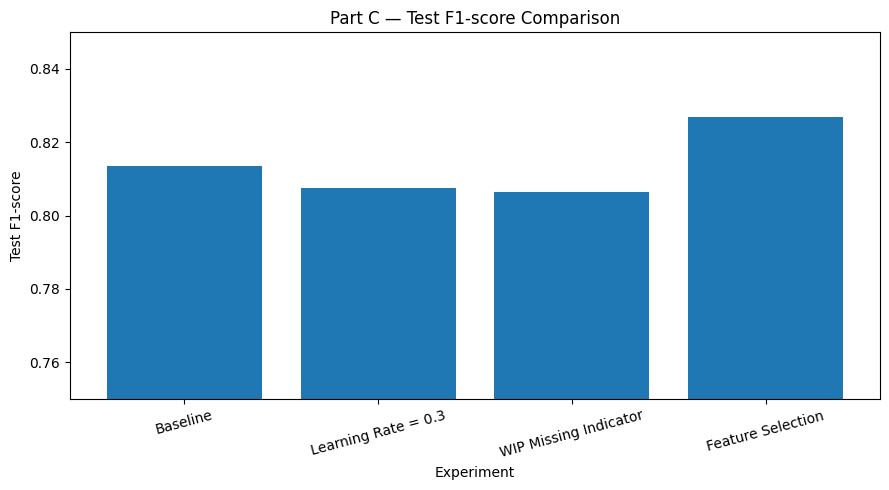

In [158]:


plt.figure(figsize=(9, 5))

plt.bar(
    part_c_results['Experiment'],
    part_c_results['Test F1']
)

plt.ylabel('Test F1-score')
plt.xlabel('Experiment')
plt.title('Part C — Test F1-score Comparison')
plt.ylim(0.75, 0.85)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

#### Conclusion

Feature selection gave the highest observed test F1-score:

**0.8136 → 0.8269**

while reducing the feature count:

**25 → 22 features**

The learning-rate and WIP-missingness experiments did not improve the test F1-score.

#### Final Optimized Model

| Property | Value |
|---|---|
| Model | Manual Logistic Regression |
| Features | 22 |
| Learning Rate | 0.1 |
| Iterations | 1000 |
| Test Accuracy | **0.7208** |
| Test Precision | **0.7547** |
| Test Recall | **0.9143** |
| Test F1-score | **0.8269** |


Feature selection produced the highest observed test metrics among the
experiments performed while reducing the number of input features from 25 to 22.